M1-M4 are the assumed models. M1-M12 are observation data-generating processes.

DeepSet, 2*num_dim, 100 observation,DeepSet,epochs=256, inference network: depth=8, widths=(256,256,256), "norm": "layer", larger training budget for M3

In [6]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

In [7]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood_20d_100n"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},

    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},

    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [8]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [9]:
# generate test datasets
datasets = {}
for source, spec in source_specs.items():
    data = GetDatasets(
        obs_mu_prior_mean=spec["mu_prior_mean"],
        obs_mu_prior_std=spec["mu_prior_std"],
        num_dims=num_dims,
        num_obs=num_obs,
        obs_likelihood_std=spec["likelihood_std"],
        num_datasets=num_datasets,
        rng=RNG,
    ).get_datasets_normal()
    for item in data:
        item["source_model"] = source
    datasets[source] = data
    save_pickle(data, dataset_dir / f"{source}_raw.pkl") # save datasets seprately for each source model

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model'])


In [10]:
datasets = {source: load_pickle(dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [11]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_20d_100n.keras"
filepath_m2 = network_dir / "m2_s_20d_100n.keras"
filepath_m3 = network_dir / "m3_s_20d_100n.keras"
filepath_m4 = network_dir / "m4_s_20d_100n.keras"
filepath_direct = network_dir / "direct_s_20d_100n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [12]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [13]:
# compute logmls and PMPs for all datasets
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model', 'gold_log_marginal_m1', 'gold_post_samples_m1', 'npe_post_samples_m1', 'npe_log_marginal_m1', 'npe_log_marginal_gp_m1', 'gold_log_marginal_m2', 'gold_post_samples_m2', 'npe_post_samples_m2', 'npe_log_marginal_m2', 'npe_log_marginal_gp_m2', 'gold_log_marginal_m3', 'gold_post_samples_m3', 'npe_post_samples_m3', 'npe_log_marginal_m3', 'npe_log_marginal_gp_m3', 'gold_log_marginal_m4', 'gold_post_samples_m4', 'npe_post_samples_m4', 'npe_log_marginal_m4', 'npe_log_marginal_gp_m4', 'p_direct', 'p_gold', 'p_npe'])


In [14]:
datasets = {source: load_pickle(dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [15]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS) 
}
distance_metric = "l2"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric,alpha=0.1)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,40,0.636564,0.893098,0.743873
m2,l2,40,0.643846,0.895263,0.748141
m3,l2,40,0.573221,0.940907,0.740914
m4,l2,40,0.639542,0.885566,0.736117


In [16]:
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / "posterior_distance_frame_20d_100n.csv", index=False)
logml_df.to_csv(result_dir / "logml_distance_frame_20d_100n.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame_20d_100n.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary_20d_100n.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary_20d_100n.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_20d_100n.pkl")


In [17]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed_20d_100n.pkl") for source in sd.SOURCE_MODELS}
posterior_df = pd.read_csv(result_dir / "posterior_distance_frame_20d_100n.csv")
logml_df = pd.read_csv(result_dir / "logml_distance_frame_20d_100n.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame_20d_100n.csv")

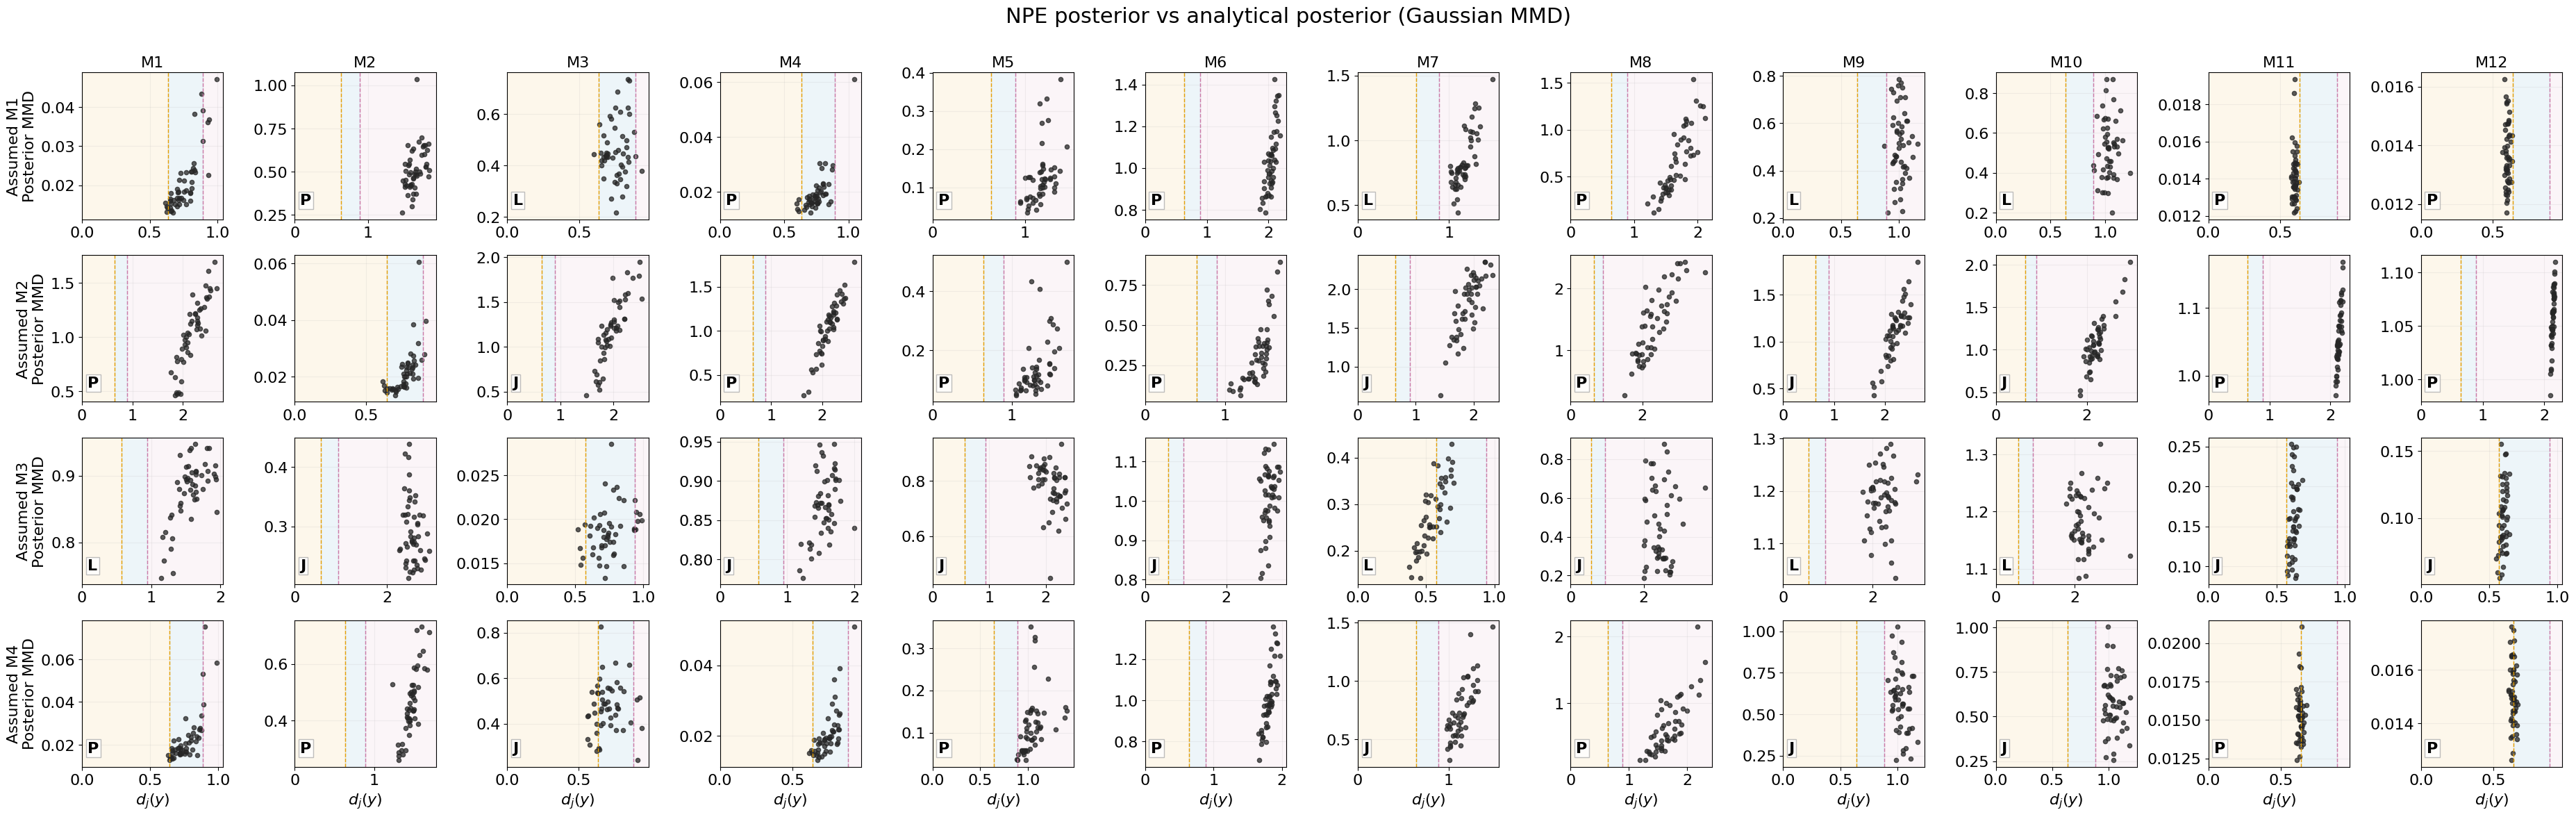

In [18]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mmd", output_dir=figure_dir, sharey=False
);


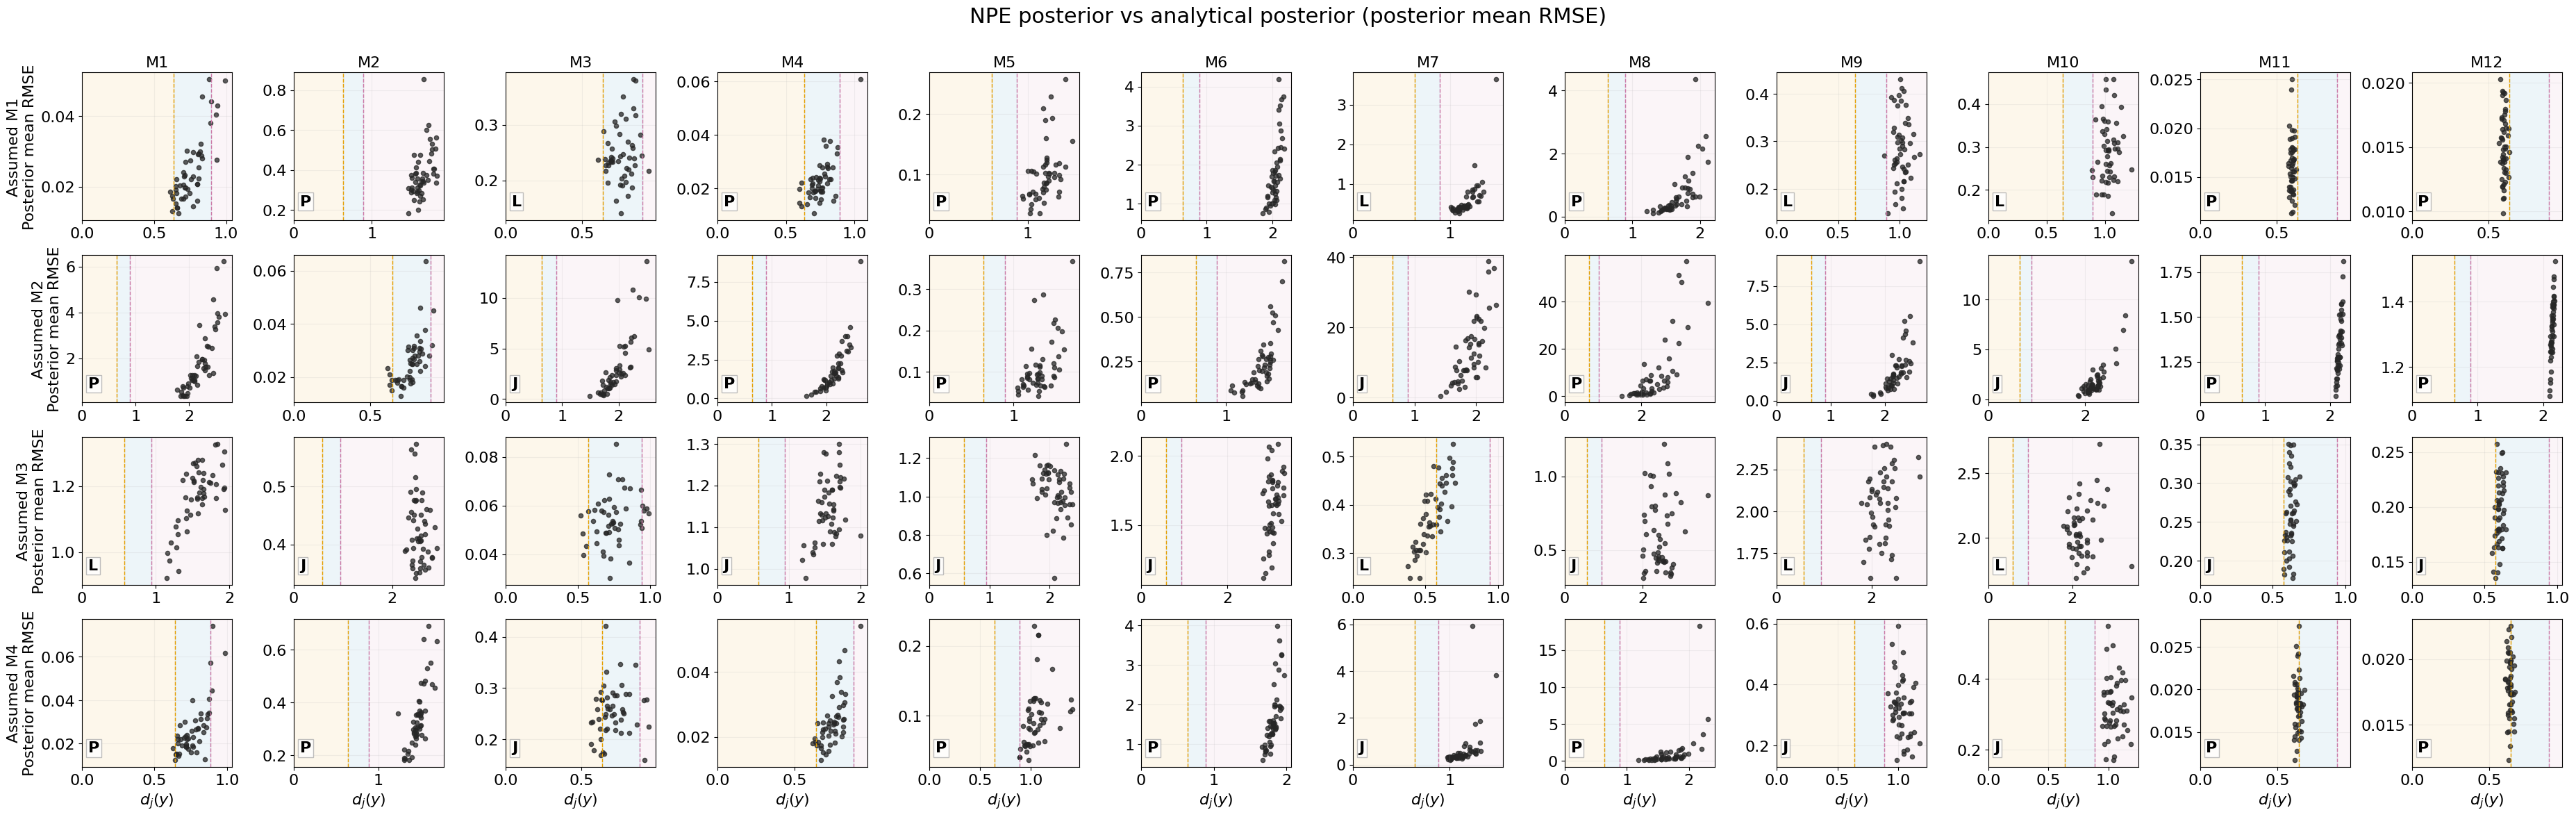

In [19]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mean_rmse", output_dir=figure_dir, sharey=False
);


## Plots

AttributeError: module 'benchmark.examples.gaussian.analysis.summry_diagnostic' has no attribute 'plot_logml_error_vs_distance'

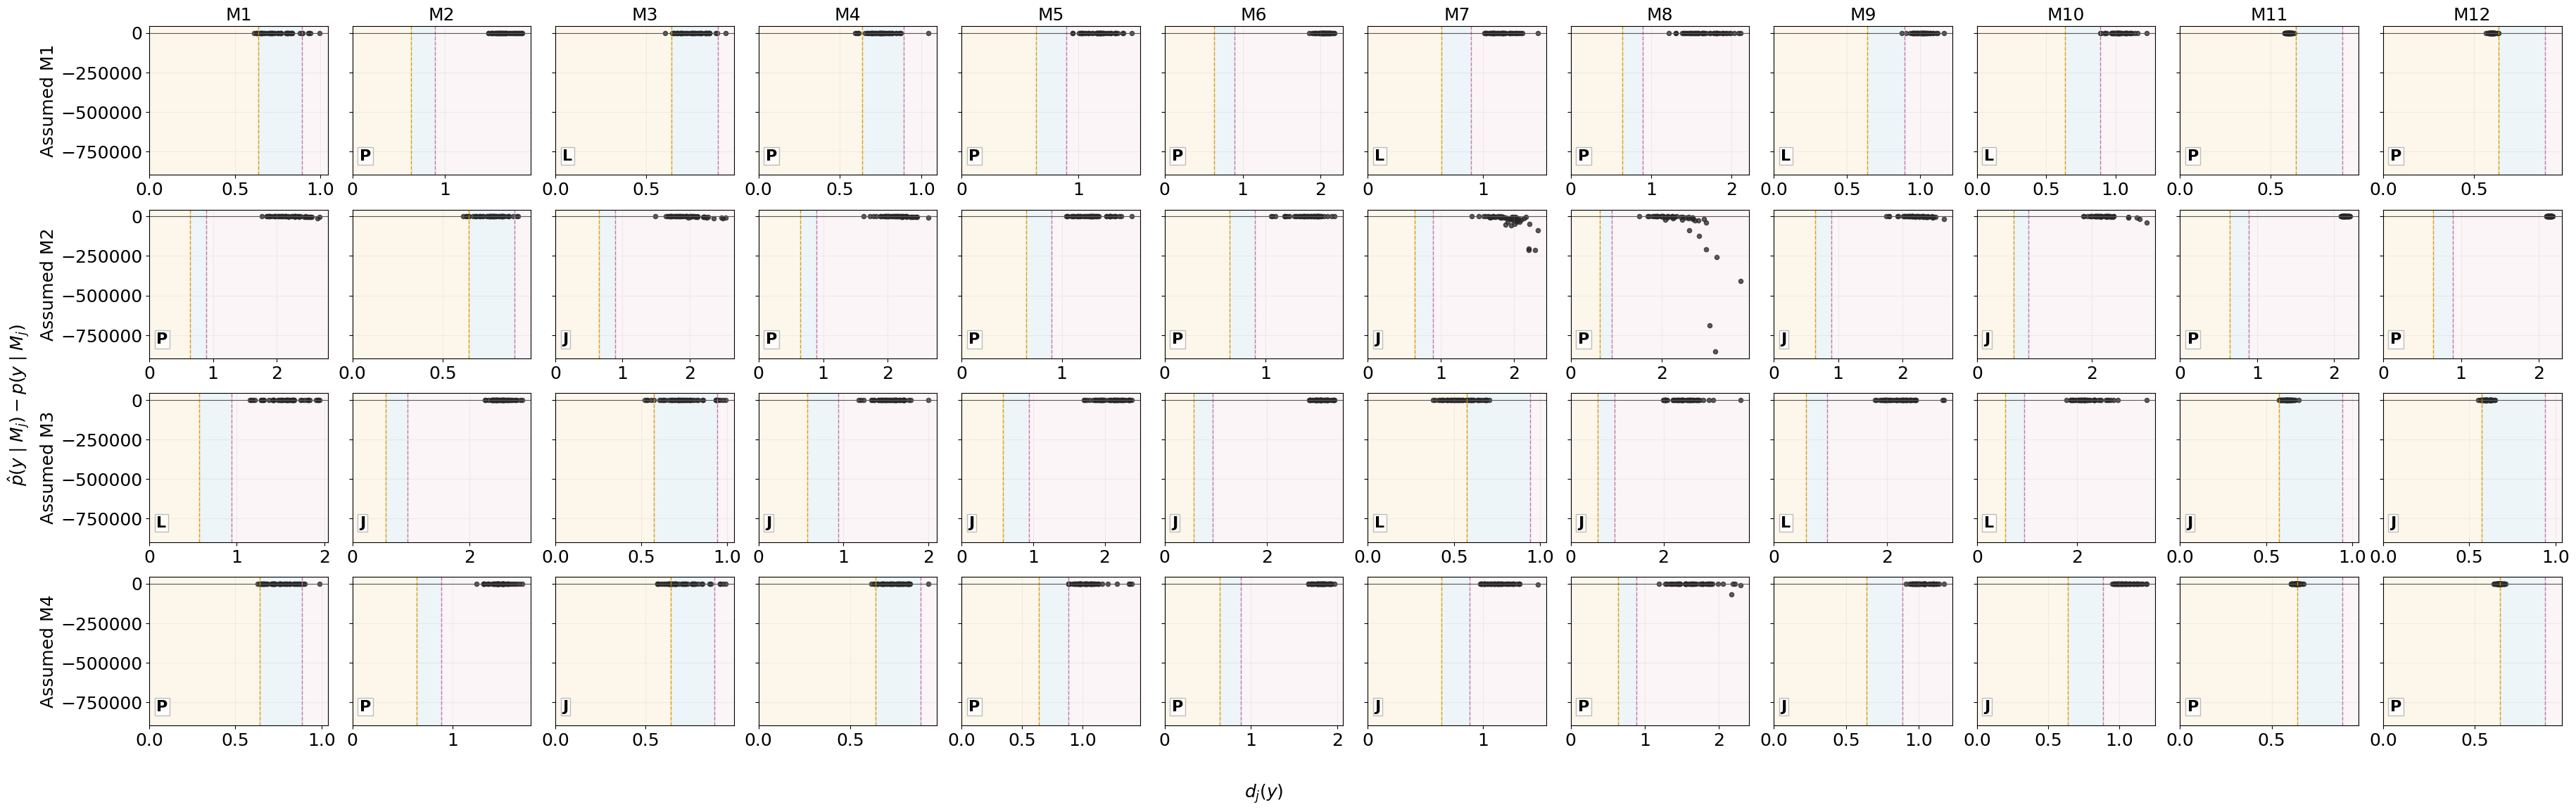

In [25]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir,error_bound=1000);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

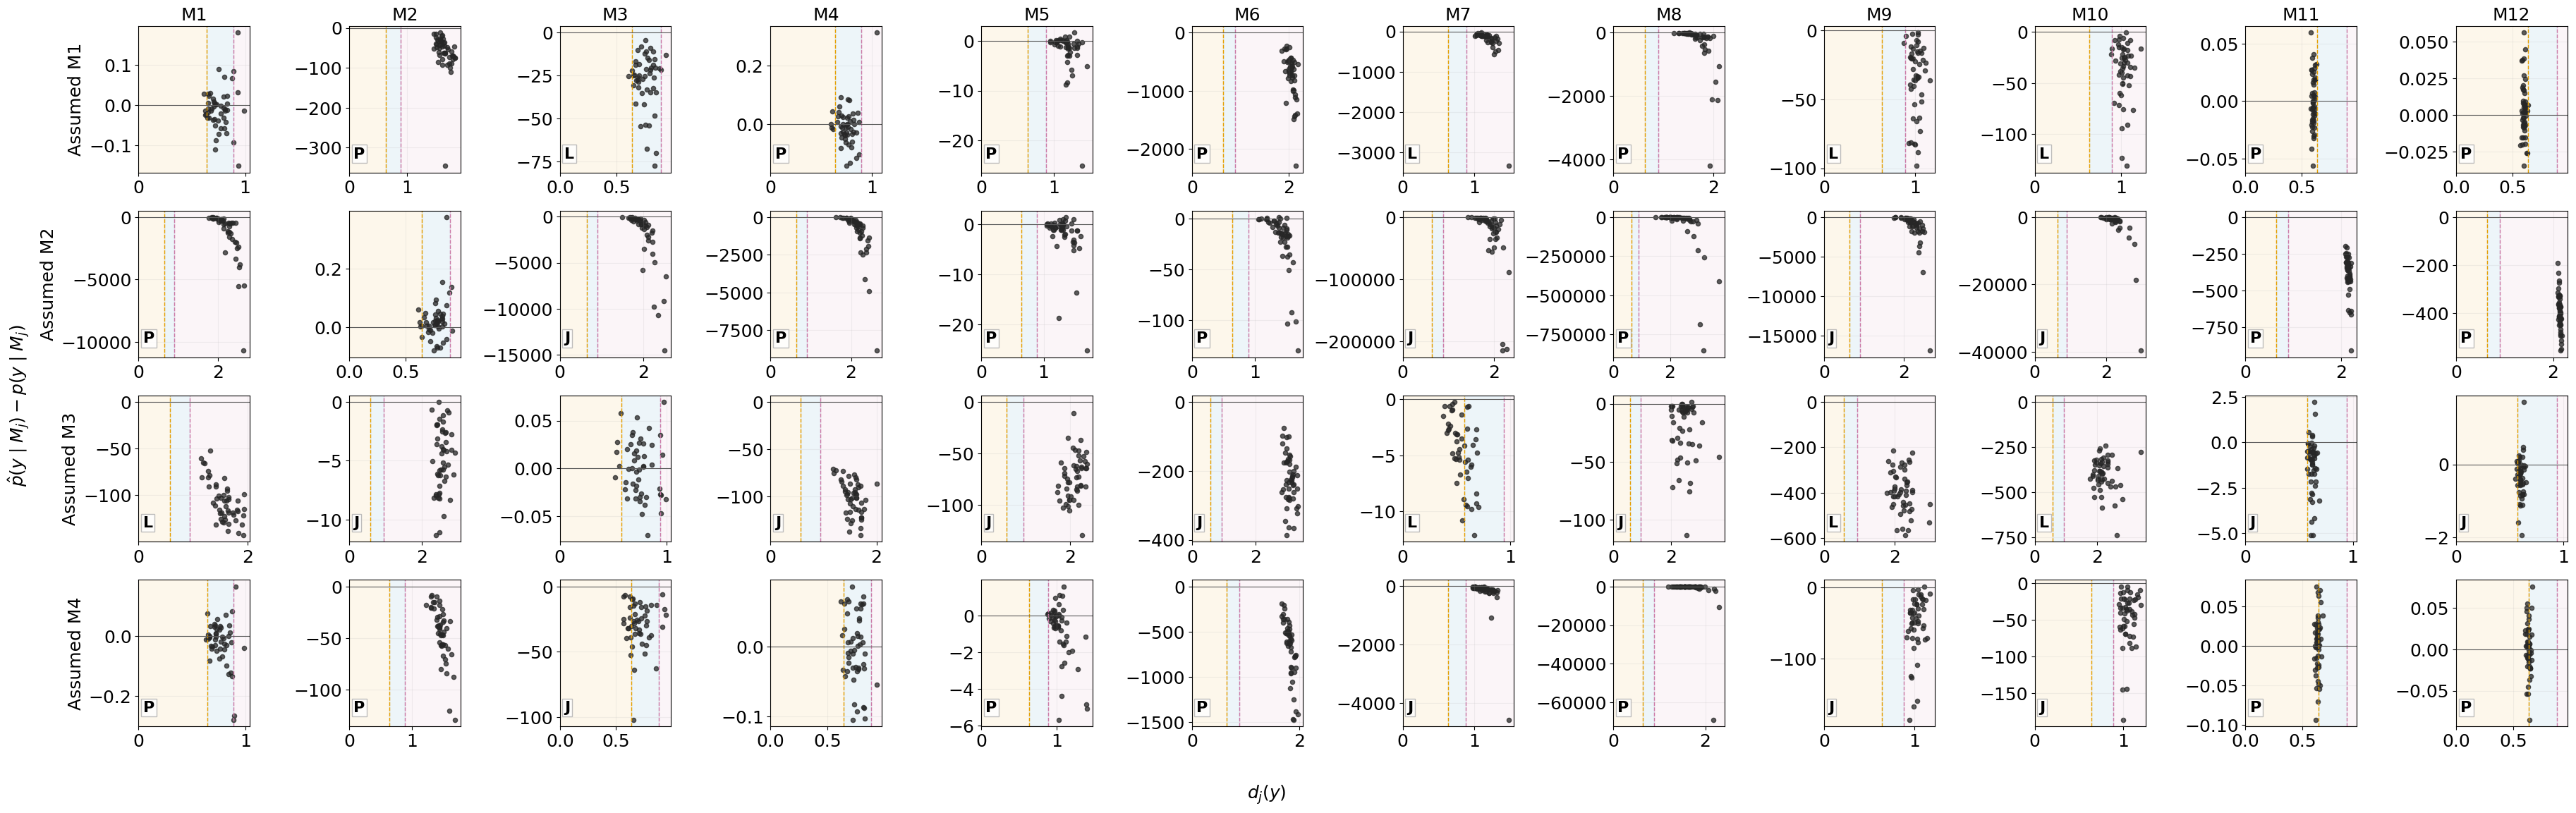

In [21]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\rho_1(y)$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\rho_2(y)$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\rho_3(y)$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\rho_4(y)$'>],
       dtype=object))

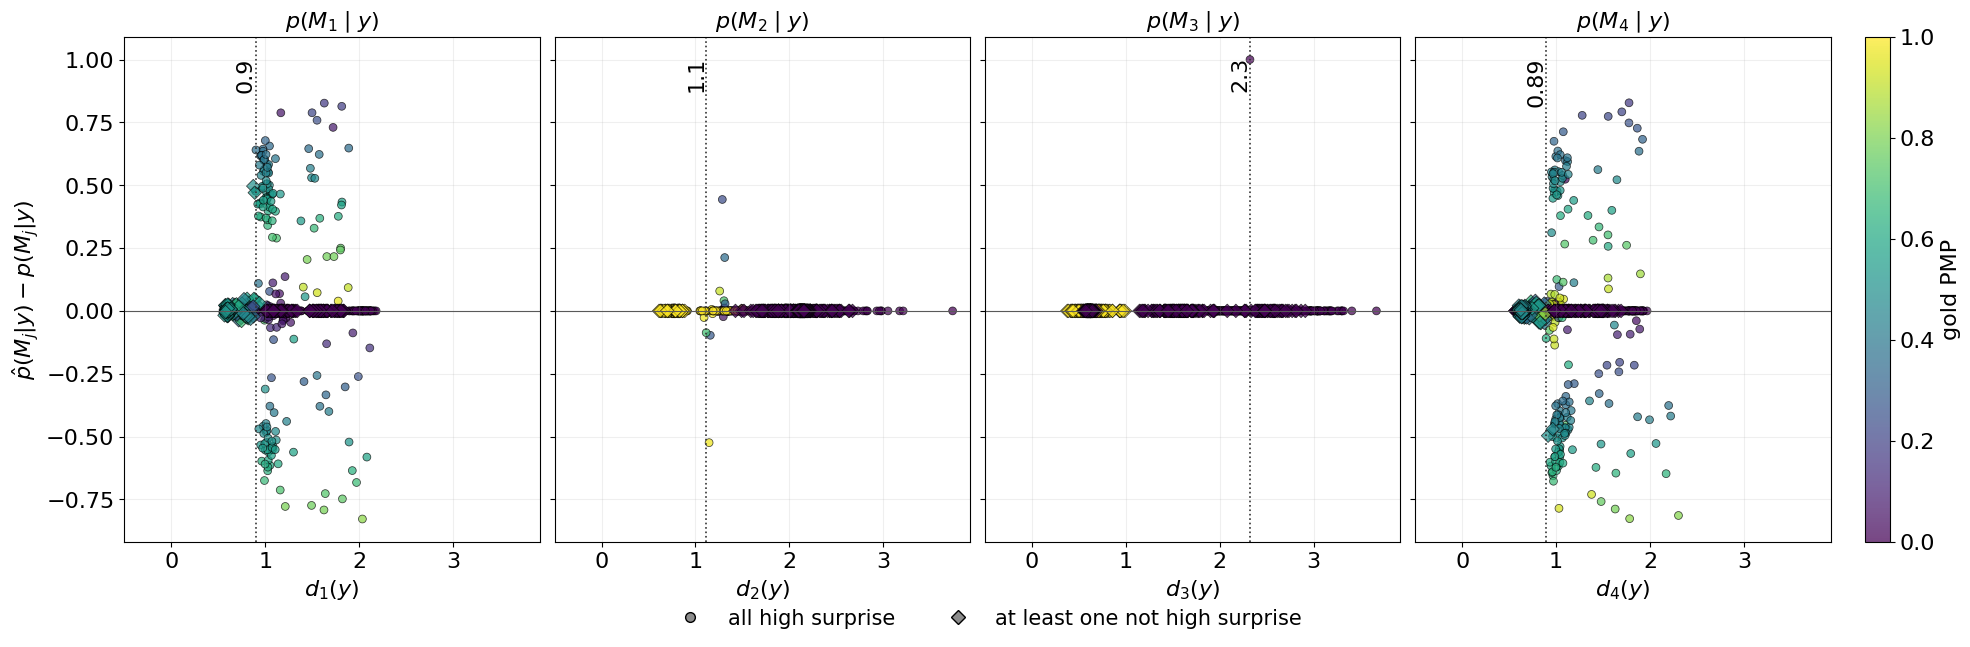

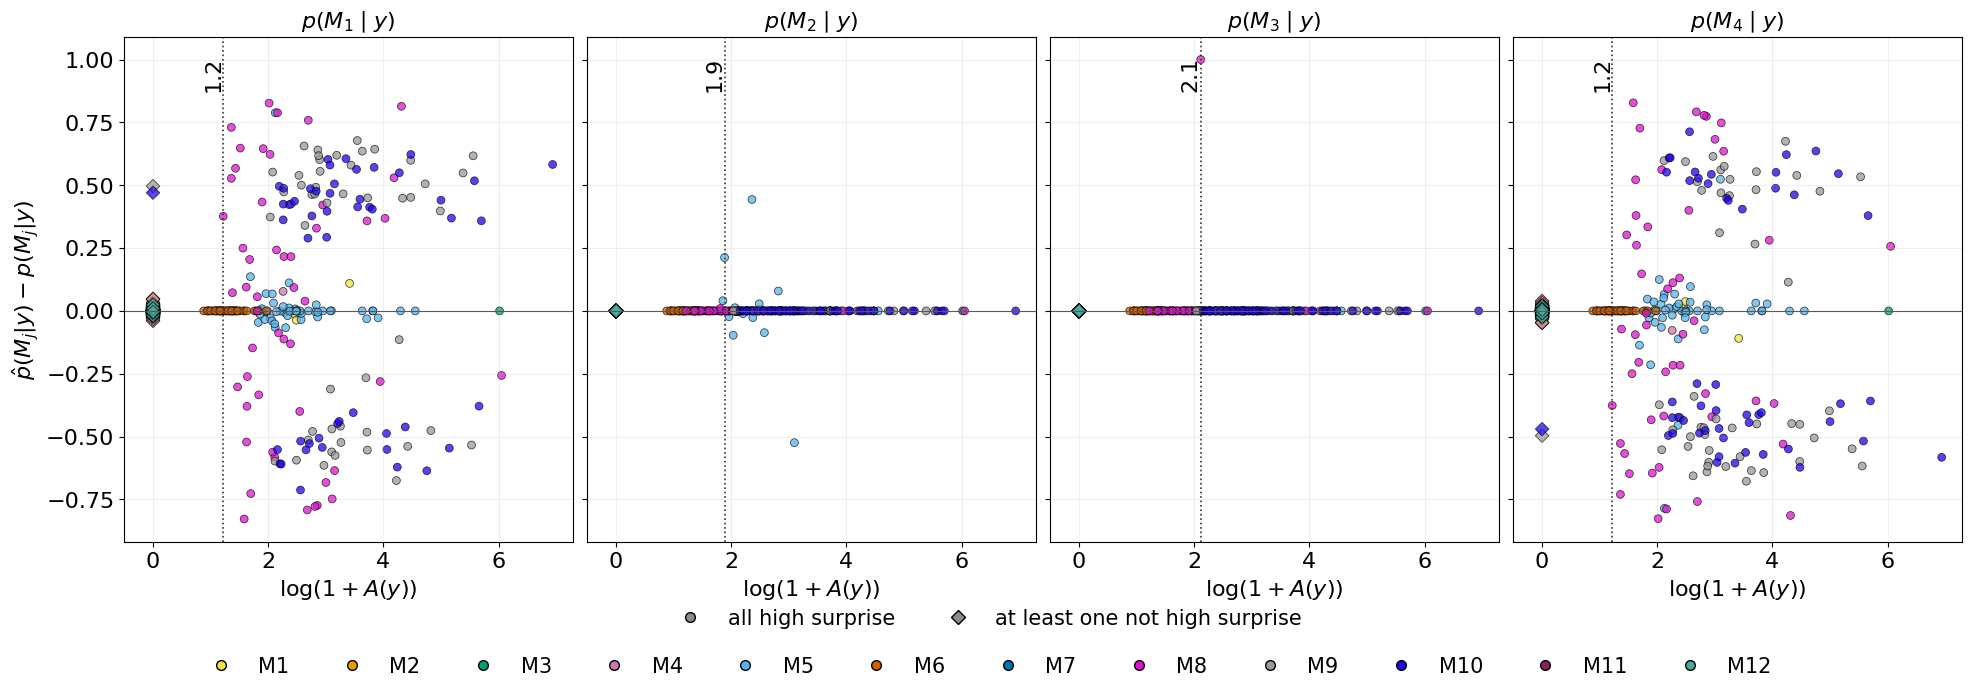

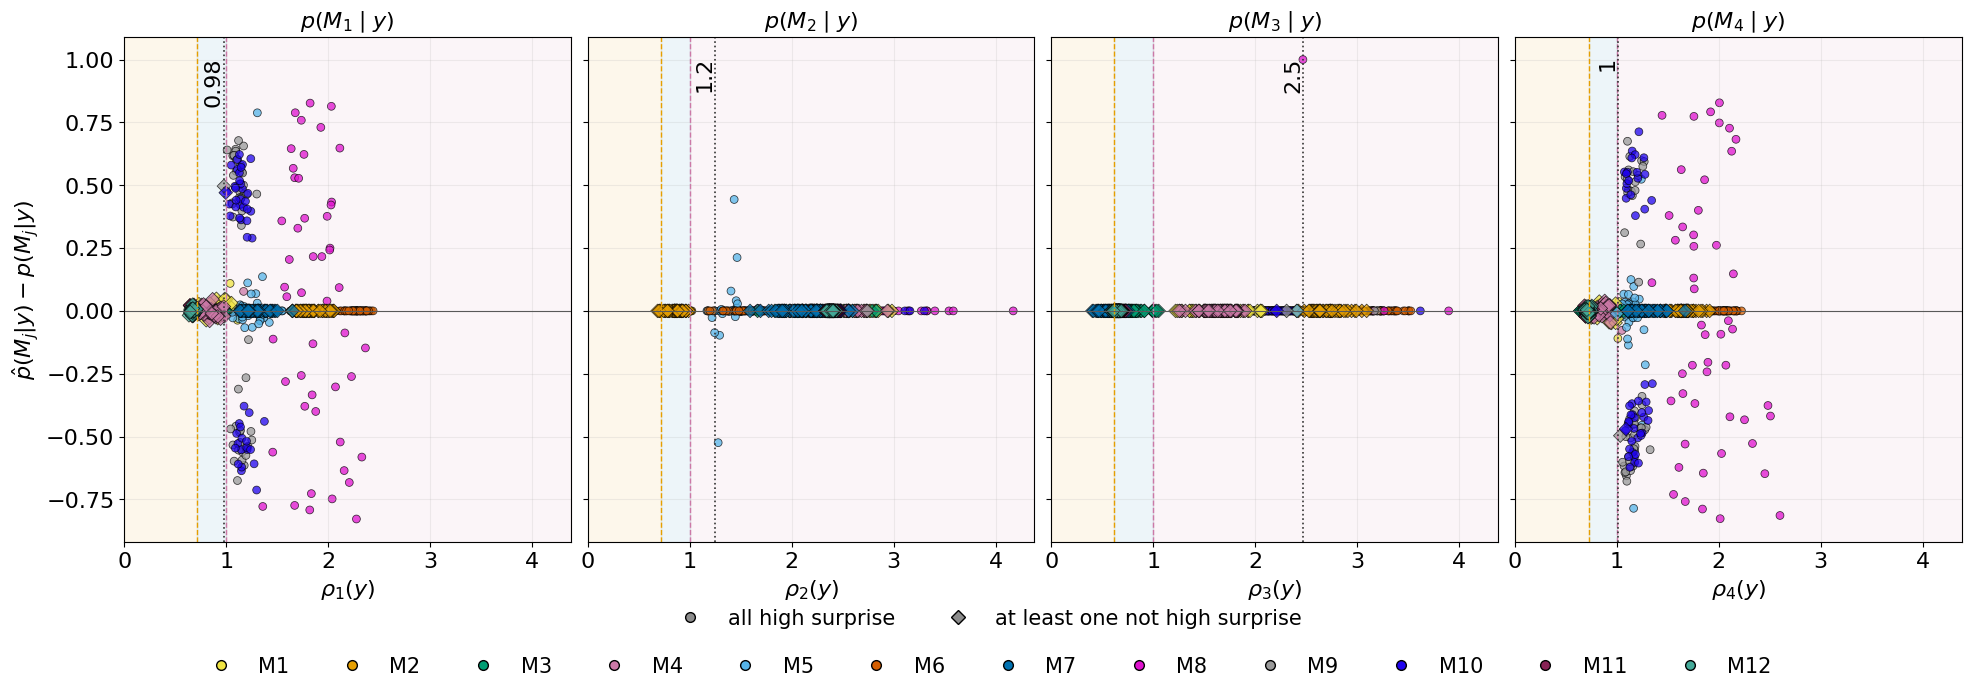

In [22]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df, x="distance", y="signed_error", group_by="global_extrapolation", estimate="npe", output_dir=figure_dir, filename="x_vs_pmp_error_npe.png", sharex=True, error_bound=0.05,error_subset="all_extrapolative")

# sd.plot_pmp_diagnostic(pmp_df, x="logA", y="signed_error", group_by="global_extrapolation", estimate="npe", output_dir=figure_dir, filename="x_vs_pmp_error_npe.png", sharex=True, error_bound=0.05,error_subset="all_extrapolative")
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.05,error_subset="all_extrapolative")
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,)


In [23]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

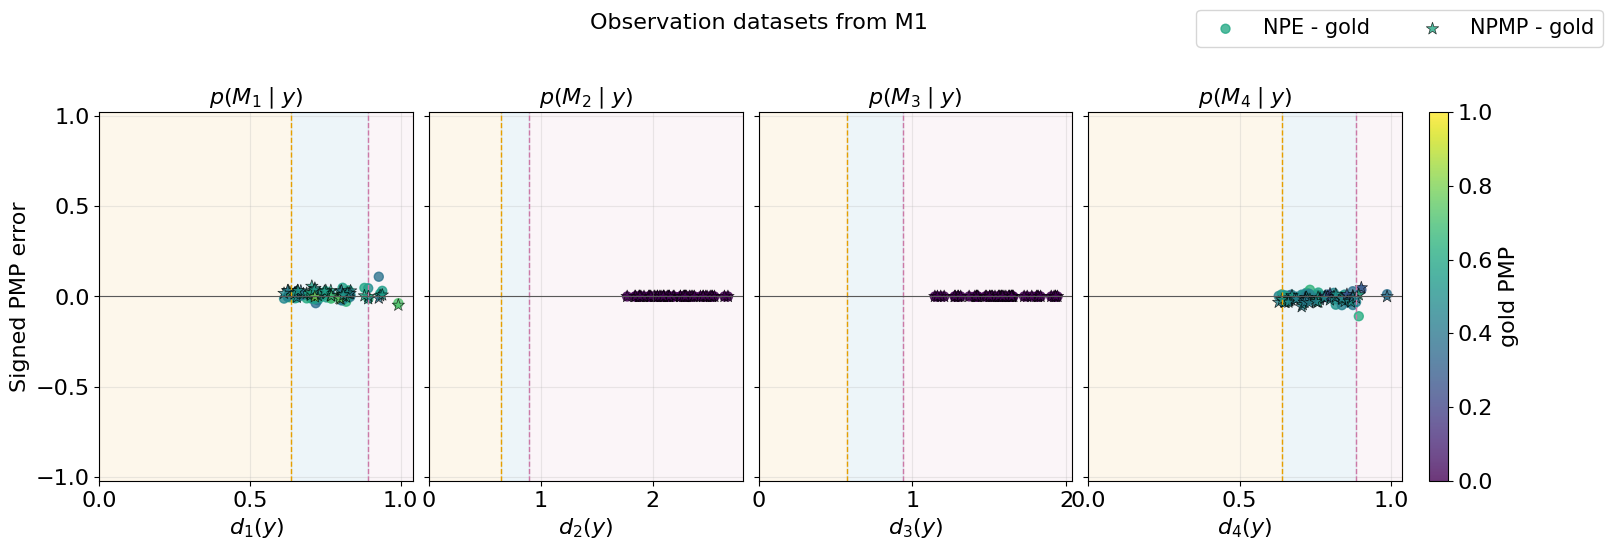

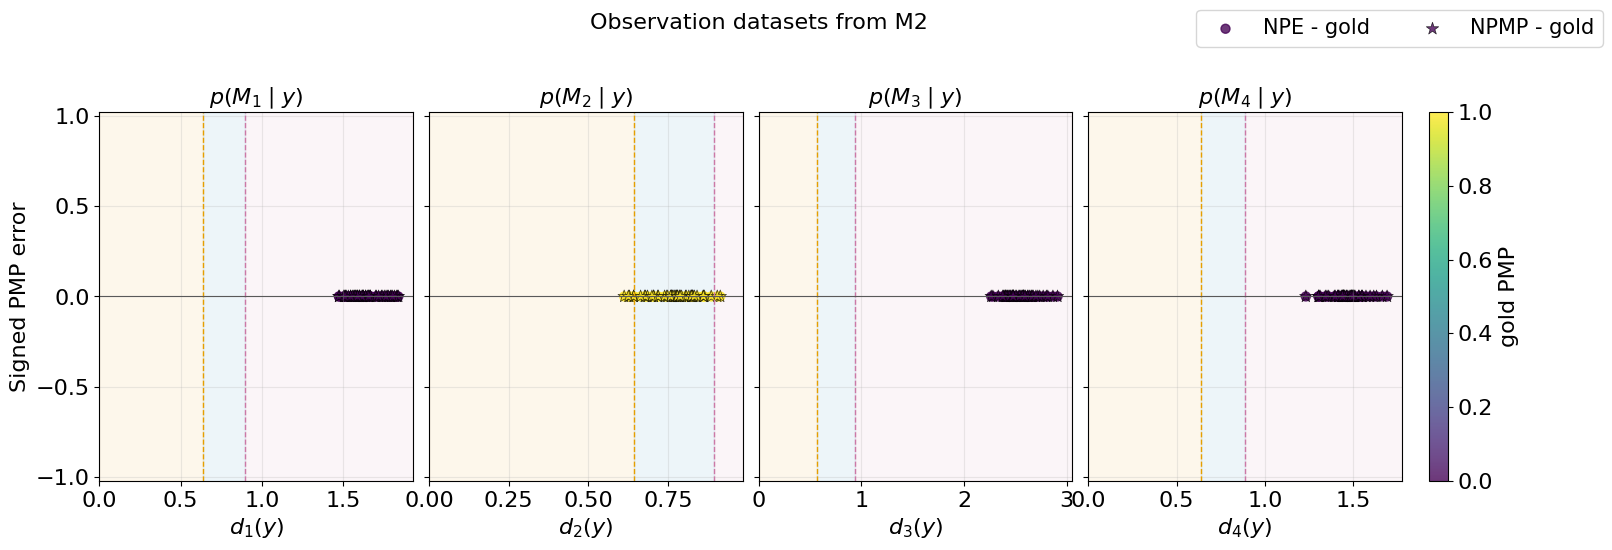

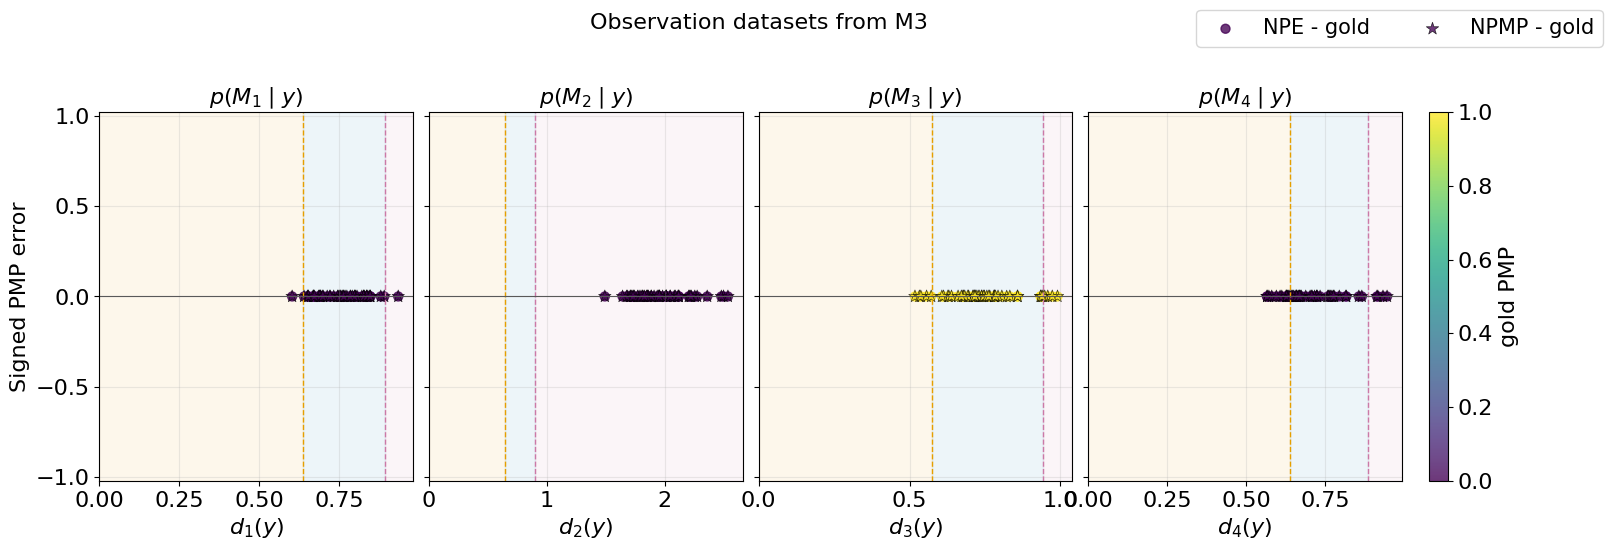

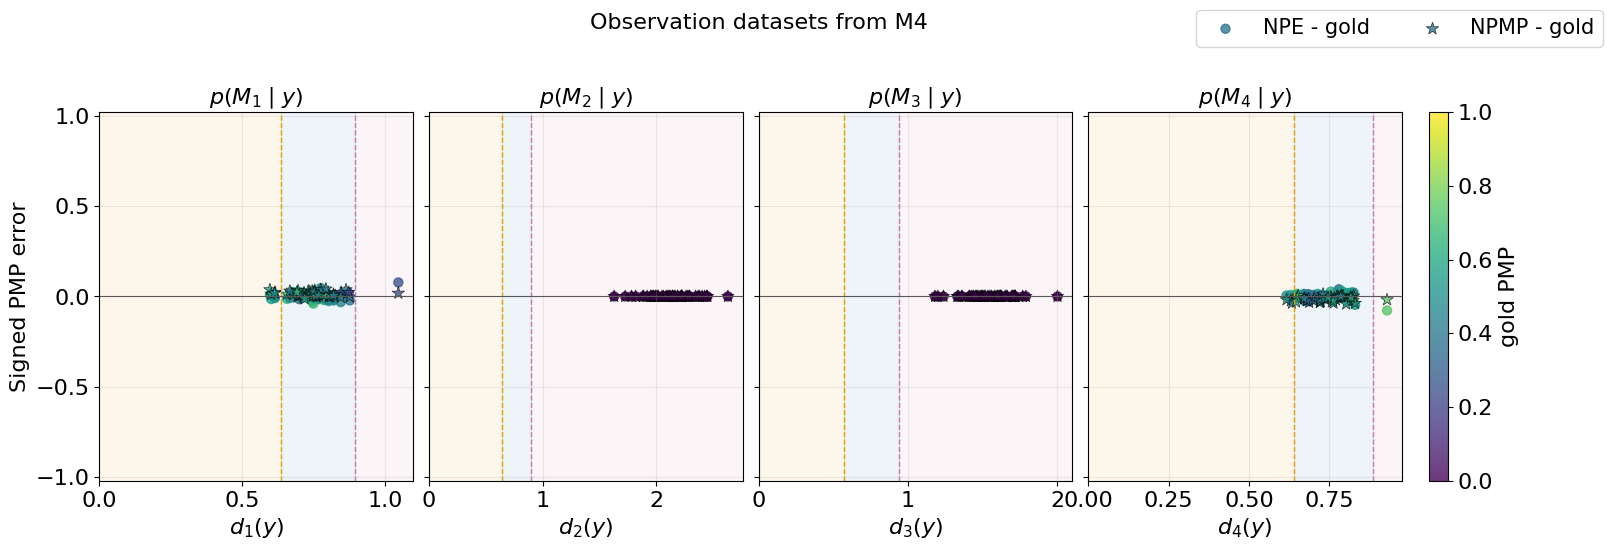

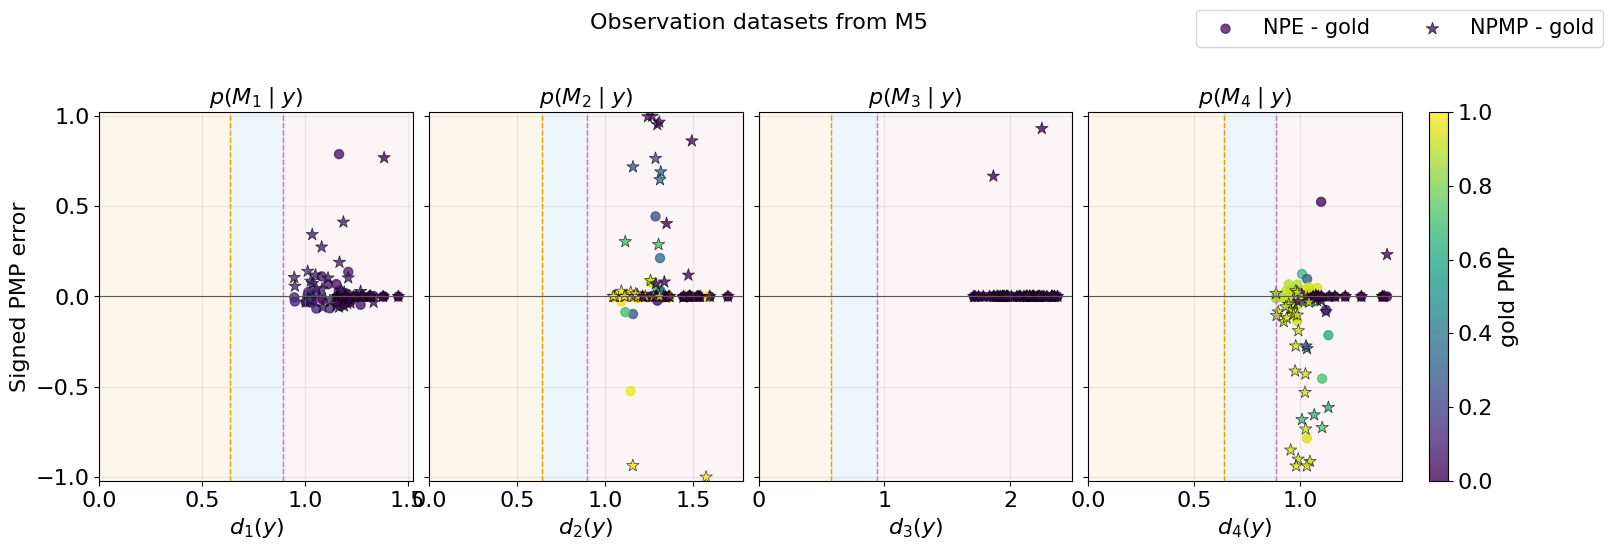

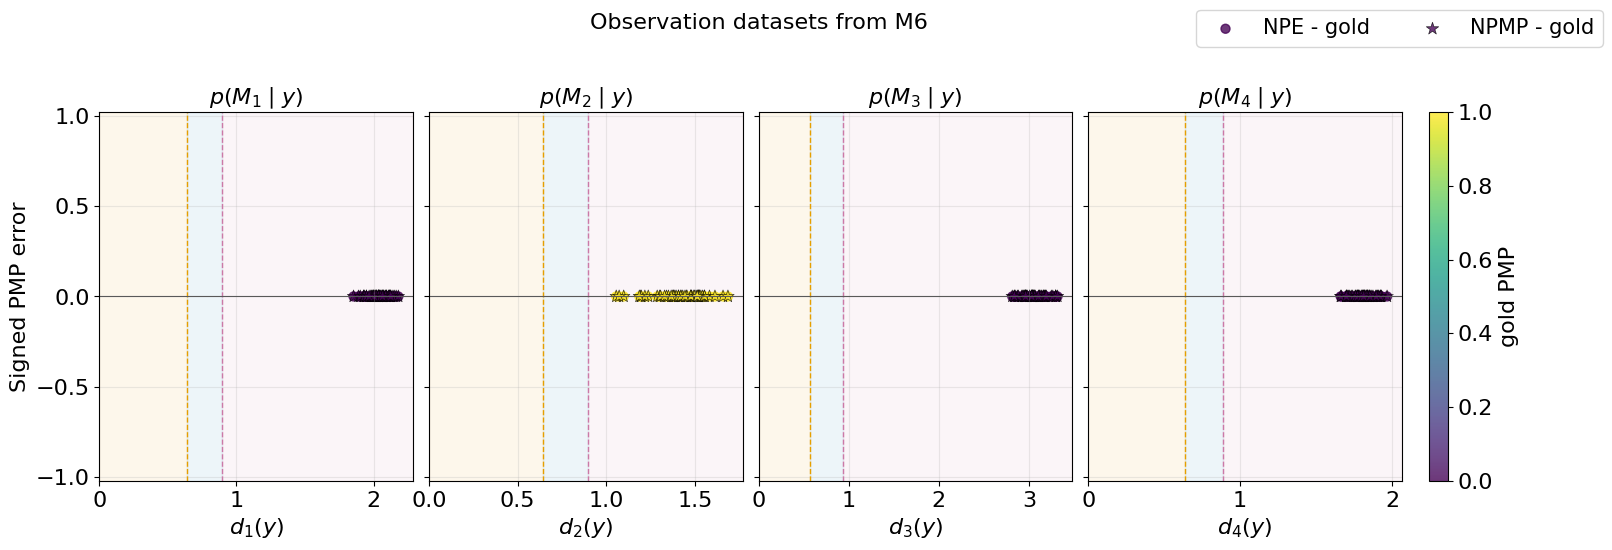

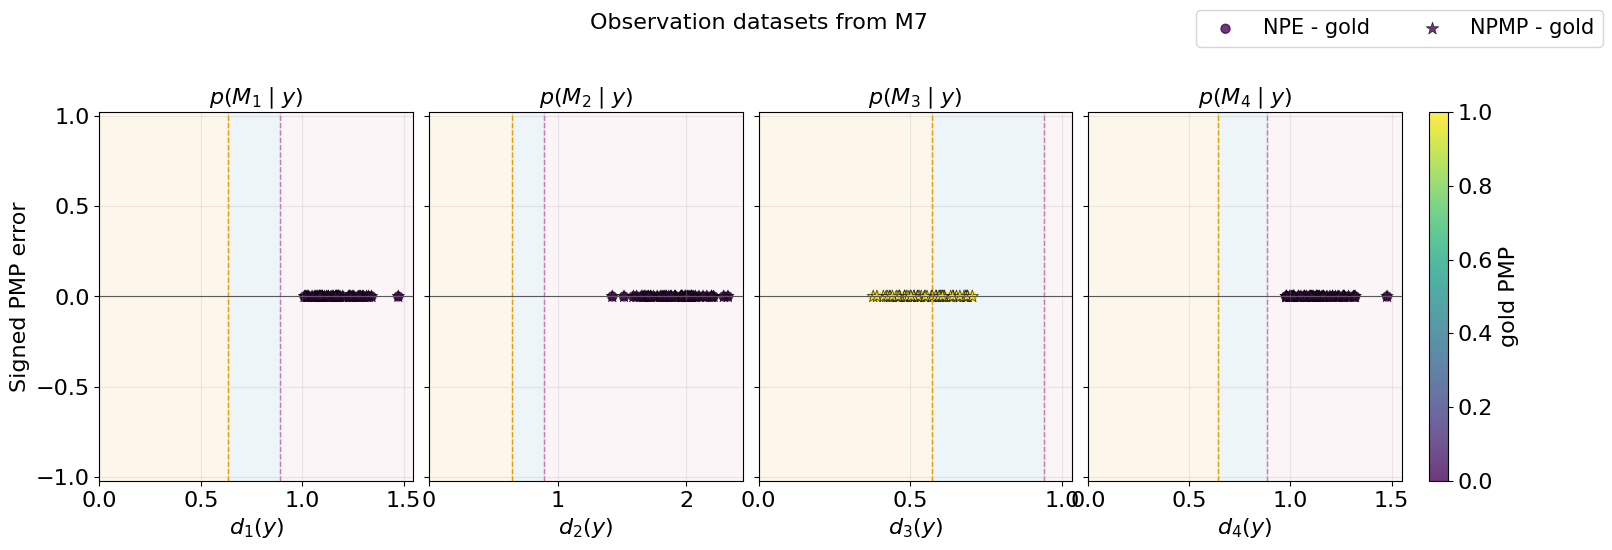

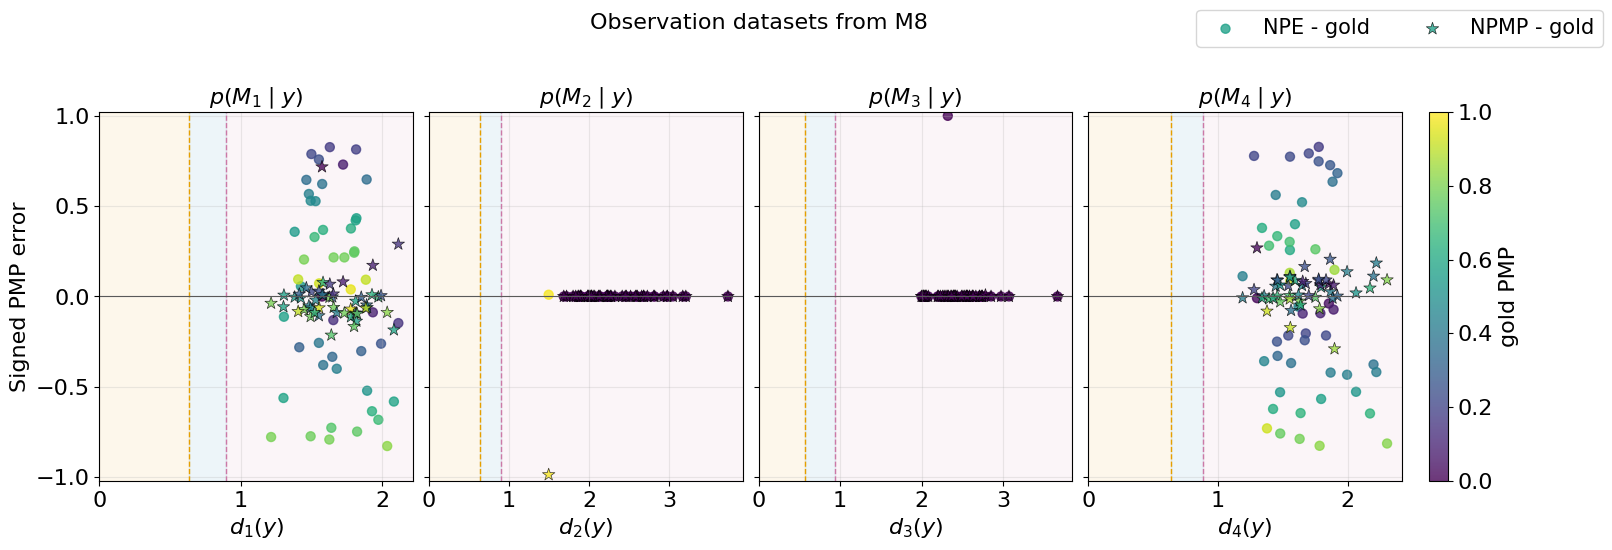

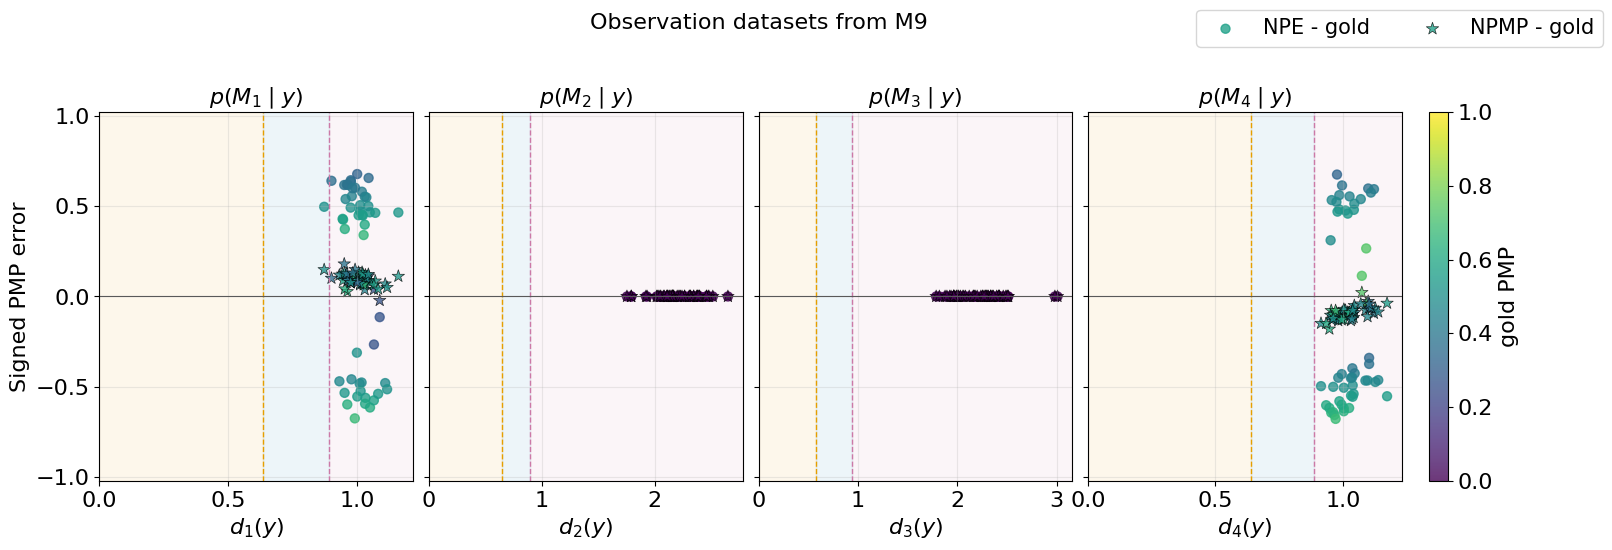

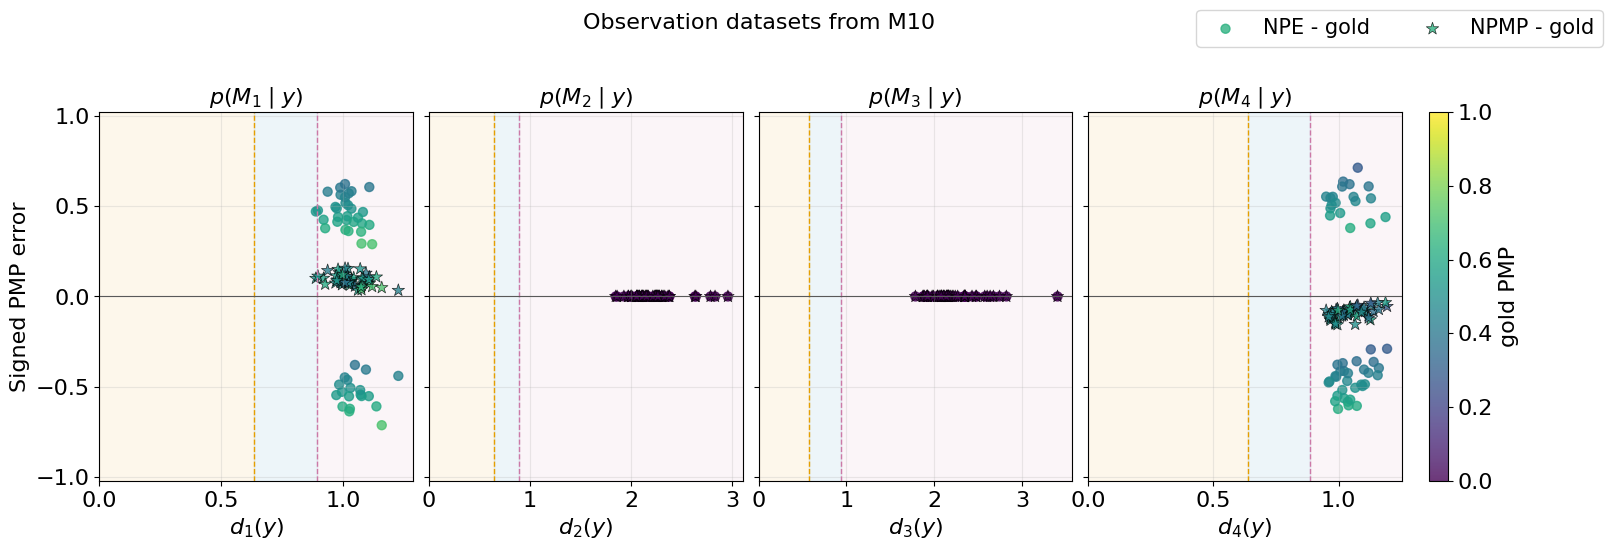

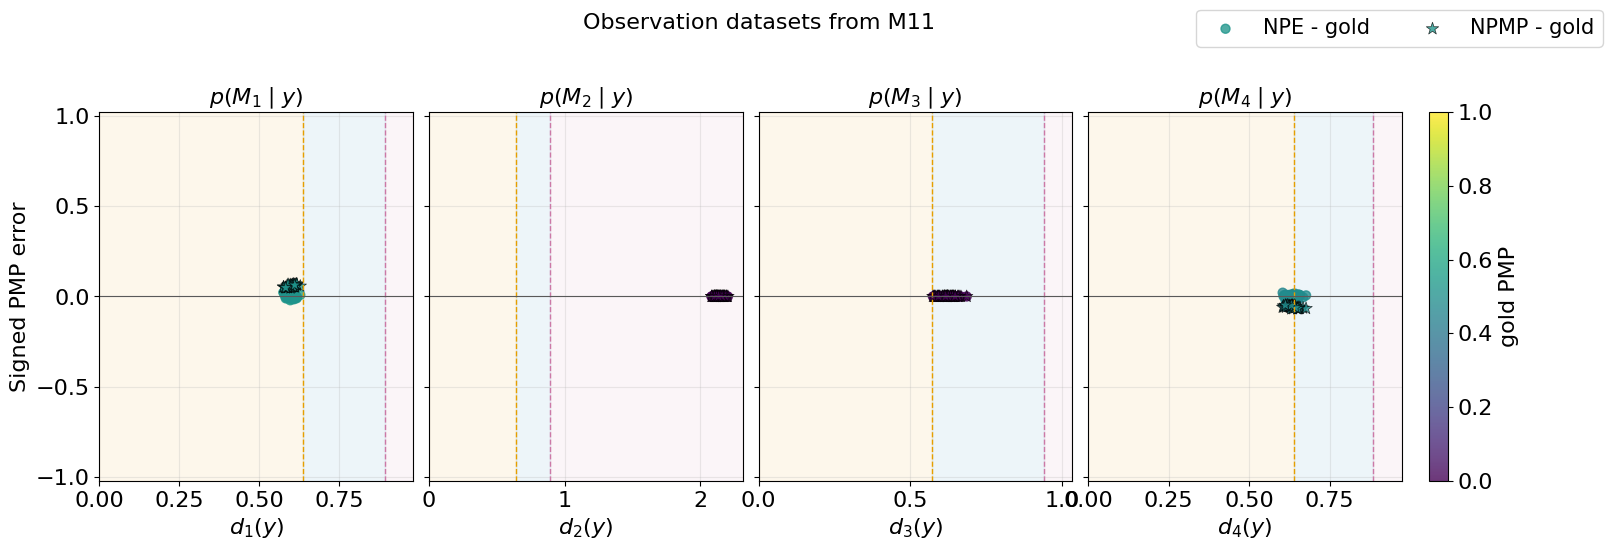

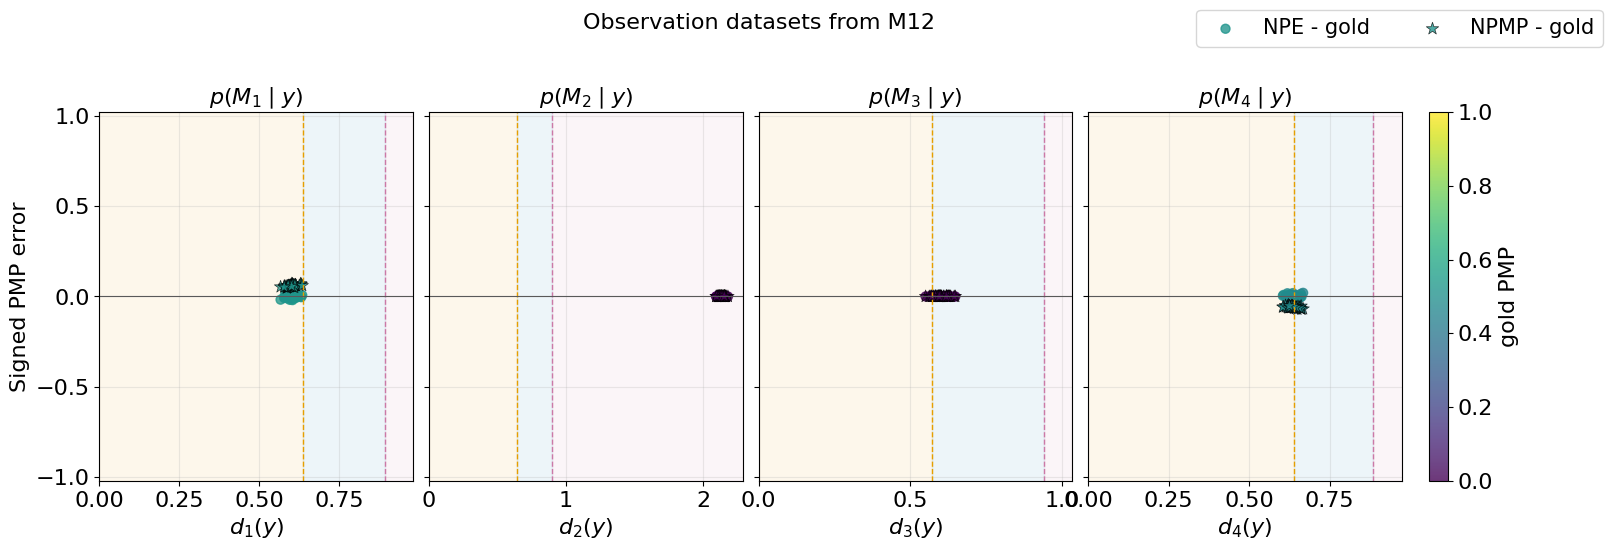

In [24]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)